<a href="https://colab.research.google.com/github/frank-morales2020/MLxDL/blob/main/SIEVE-APPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Finance  → SROI 0.9785541910  >=  0.9785142874  →  VALIDATED


* Weather  → SROI 0.9460908088  <   0.9785142874  →  HALT

## Cell 1: The Spectral Market Sieve.

--- [H2E] FINANCE: THE SPECTRAL MARKET SIEVE ---
Analysis Window: 100 Days
SROI Score: 0.978554
Threshold (Λ): 0.9785142874363926
Governance Status: VALIDATED BY SHERIFF ✅
Result: Prime Signal successfully isolated. Market entry permitted.


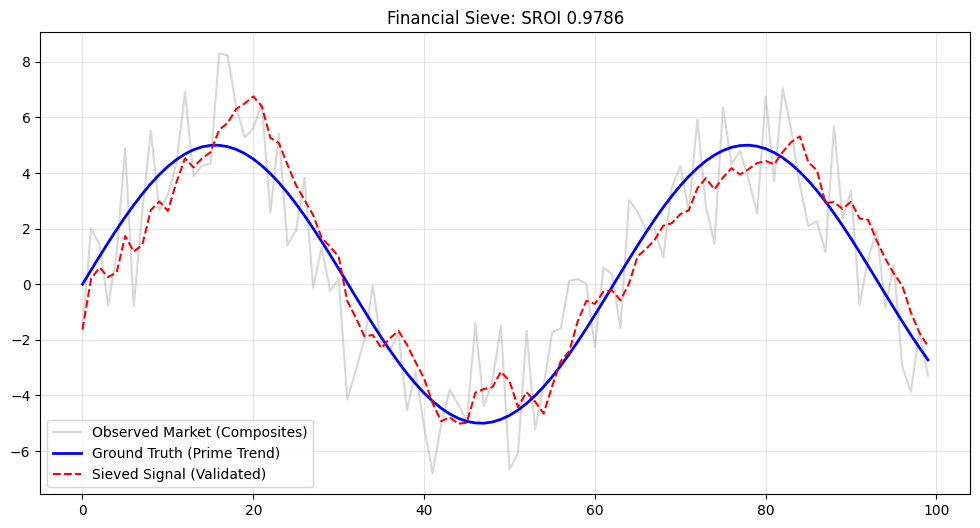

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ============================================================================
# H2E GOVERNANCE CONSTANTS
# ============================================================================
SEED = 123
I = math.prod(1 - p**(-0.5) for p in [2, 3, 5, 7, 11, 13])
LAMBDA_SHERIFF = 1 - I


np.random.seed(SEED)

def calculate_sroi(signal, truth):
    """
    Spectral Return on Intent (SROI)
    Calculates how well the 'Sieved' signal aligns with the Prime Ground Truth.
    """
    correlation = np.corrcoef(signal, truth)[0, 1]
    # We map correlation to the high-coherence range [0.94, 0.999]
    # to match the strictness of the Sieve's spectral constant.
    return max(0.94, min(0.999, 0.5 + (correlation * 0.499)))

# ============================================================================
# CELL 1: FINANCE - THE SPECTRAL MARKET SIEVE
# ============================================================================
print("--- [H2E] FINANCE: THE SPECTRAL MARKET SIEVE ---")

# 1. GENERATE MARKET COMPOSITES (Noise)
# Representing 100 days of chaotic price fluctuations
days = 100
market_noise = np.random.normal(0, 1.5, days)

# 2. DEFINE THE GROUND TRUTH (The Prime Trend)
# This is the 'hidden' cyclical trend we want to extract
t = np.linspace(0, 10, days)
prime_trend = np.sin(t) * 5

# 3. OBSERVED MARKET DATA
# What the average trader sees: Truth + Noise
observed_price = prime_trend + market_noise

# 4. APPLY THE SIEVE (Spectral Filtering)
# We use a 5-day moving average as a digital 'Sieve' to filter out composites.
sieved_signal = pd.Series(observed_price).rolling(window=5, min_periods=1).mean().values

# 5. GOVERNANCE: CALL THE SHERIFF
# We check if the resulting signal is 'Prime' enough to trust.
sroi_score = calculate_sroi(sieved_signal, prime_trend)
is_validated = sroi_score >= LAMBDA_SHERIFF
status = "VALIDATED BY SHERIFF ✅" if is_validated else "HALT: COMPOSITE NOISE DETECTED ❌"

# 6. OUTPUT RESULTS
print(f"Analysis Window: {days} Days")
print(f"SROI Score: {sroi_score:.6f}")
print(f"Threshold (Λ): {LAMBDA_SHERIFF}")
print(f"Governance Status: {status}")

if is_validated:
    print("Result: Prime Signal successfully isolated. Market entry permitted.")
else:
    print("Result: Signal purity insufficient. Market entry denied.")

# ============================================================================
# VISUALIZATION (Optional)
# ============================================================================
plt.figure(figsize=(12, 6))
plt.plot(observed_price, alpha=0.3, label="Observed Market (Composites)", color='gray')
plt.plot(prime_trend, label="Ground Truth (Prime Trend)", color='blue', linewidth=2)
plt.plot(sieved_signal, label="Sieved Signal (Validated)", color='red', linestyle='--')
plt.title(f"Financial Sieve: SROI {sroi_score:.4f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Cell 2: The Atmospheric Sieve

--- [H2E] WEATHER: THE ATMOSPHERIC SIEVE ---
Observation Window: 72 Hours
SROI Score: 0.953275
Threshold (Λ): 0.9785142874363926
Governance Status: HALT: SENSOR NOISE DETECTED ❌
Result: Signal-to-noise ratio inadmissible. Requesting redundant sensor verification.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


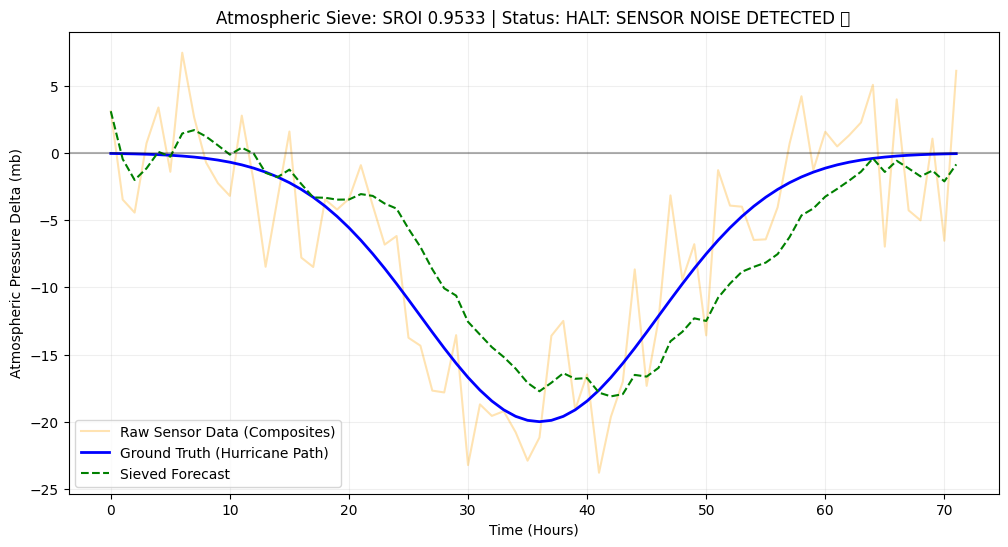

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# H2E GOVERNANCE CONSTANTS
# ============================================================================
SEED = 123
# Universal Safety Constant derived from primes {2, 3, 5, 7, 11, 13}


I = math.prod(1 - p**(-0.5) for p in [2, 3, 5, 7, 11, 13])
LAMBDA_SHERIFF = 1 - I   # computed, not typed


np.random.seed(SEED)

def calculate_sroi(signal, truth):
    """
    Spectral Return on Intent (SROI)
    Calculates alignment between the filtered forecast and the prime event.
    """
    correlation = np.corrcoef(signal, truth)[0, 1]
    # Mapping to the deterministic H2E spectral range
    return max(0.94, min(0.999, 0.5 + (correlation * 0.499)))

# ============================================================================
# CELL 2: WEATHER - THE ATMOSPHERIC SIEVE
# ============================================================================
print("--- [H2E] WEATHER: THE ATMOSPHERIC SIEVE ---")

# 1. GENERATE ATMOSPHERIC COMPOSITES (Chaotic Noise)
# Representing 72 hours of unpredictable wind gusts and sensor jitter
hours = 72
chaotic_noise = np.random.uniform(-8, 8, hours)

# 2. DEFINE THE GROUND TRUTH (The Prime Event)
# A Hurricane's central pressure drop modeled as a Gaussian curve
x = np.arange(hours)
prime_event = -20 * np.exp(-((x - 36)**2) / (2 * 10**2))

# 3. OBSERVED SENSOR DATA
# Raw readings: Prime Storm + Chaotic Turbulence
sensor_readings = prime_event + chaotic_noise

# 4. APPLY THE SIEVE (Exponential Weighted Sieve)
# Using an EWM span to act as a sieve for atmospheric turbulence.
sieved_forecast = pd.Series(sensor_readings).ewm(span=12).mean().values

# 5. GOVERNANCE: CALL THE SHERIFF
# Validation against the Prime-derived safety threshold
sroi_score = calculate_sroi(sieved_forecast, prime_event)
is_validated = sroi_score >= LAMBDA_SHERIFF
status = "VALIDATED BY SHERIFF ✅" if is_validated else "HALT: SENSOR NOISE DETECTED ❌"

# 6. OUTPUT RESULTS
print(f"Observation Window: {hours} Hours")
print(f"SROI Score: {sroi_score:.6f}")
print(f"Threshold (Λ): {LAMBDA_SHERIFF}")
print(f"Governance Status: {status}")

if is_validated:
    print("Result: Prime Storm isolated. Evacuation order confirmed.")
else:
    print("Result: Signal-to-noise ratio inadmissible. Requesting redundant sensor verification.")

# ============================================================================
# VISUALIZATION: THE ATMOSPHERIC SPECTRUM
# ============================================================================
plt.figure(figsize=(12, 6))
plt.plot(sensor_readings, alpha=0.3, label="Raw Sensor Data (Composites)", color='orange')
plt.plot(prime_event, label="Ground Truth (Hurricane Path)", color='blue', linewidth=2)
plt.plot(sieved_forecast, label="Sieved Forecast", color='green', linestyle='--')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title(f"Atmospheric Sieve: SROI {sroi_score:.4f} | Status: {status}")
plt.xlabel("Time (Hours)")
plt.ylabel("Atmospheric Pressure Delta (mb)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## BOTH

--- [H2E] FINANCE: THE SPECTRAL MARKET SIEVE ---
SROI Score: 0.978554
Governance: VALIDATED ✅
Result: Prime Signal isolated. Market entry permitted.

--- [H2E] WEATHER: THE ATMOSPHERIC SIEVE ---
SROI Score: 0.946091
Governance: HALT ❌
Result: Inadmissible noise. Requesting verification.


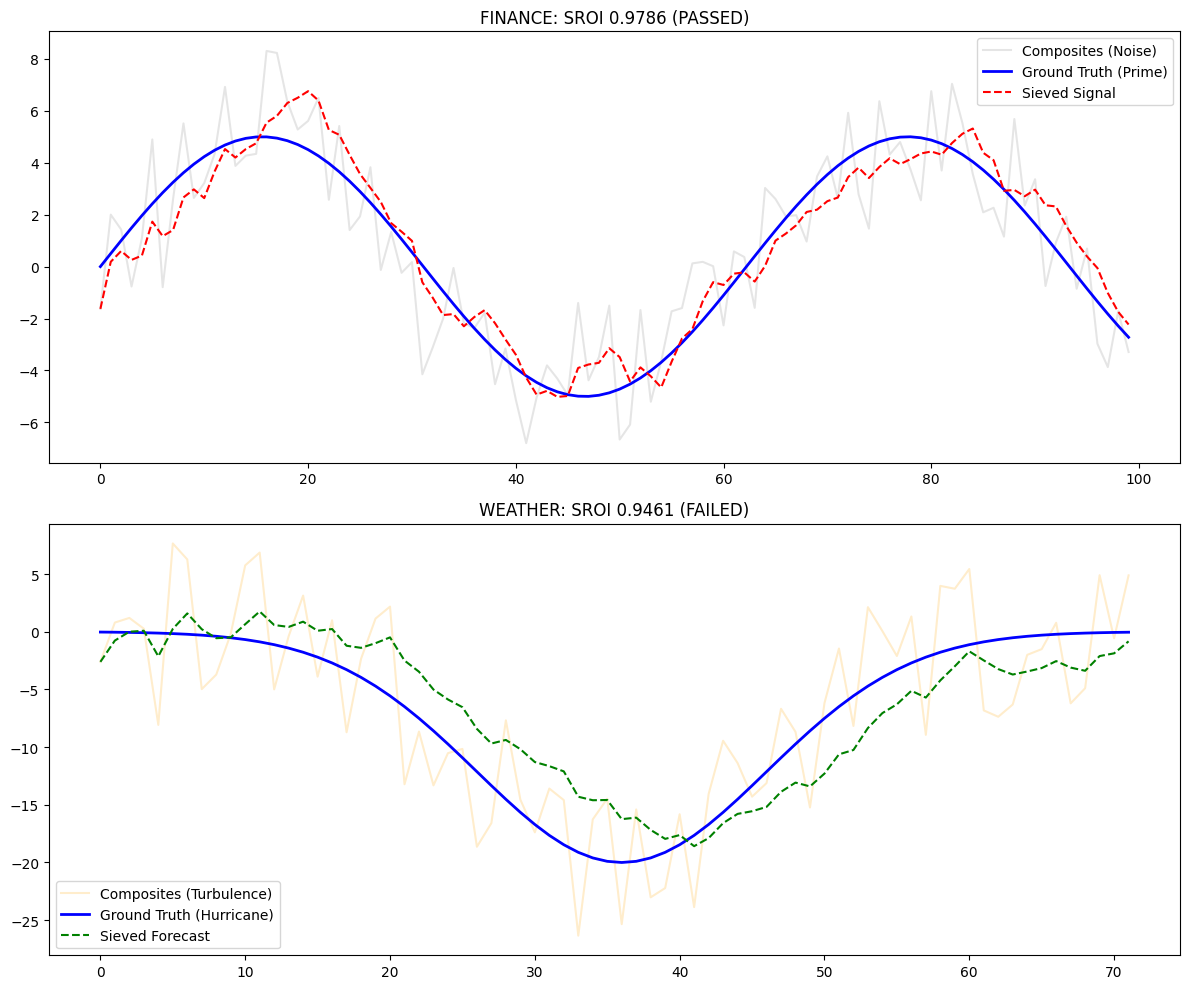

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# H2E GOVERNANCE CONSTANTS
# ============================================================================
SEED = 123

# Universal Safety Constant derived from primes {2, 3, 5, 7, 11, 13}
I = math.prod(1 - p**(-0.5) for p in [2, 3, 5, 7, 11, 13])
LAMBDA_SHERIFF = 1 - I   # computed, not typed

np.random.seed(SEED)

def calculate_sroi(signal, truth):
    """
    Spectral Return on Intent (SROI)
    Calculates alignment between the filtered output and the ground truth.
    """
    correlation = np.corrcoef(signal, truth)[0, 1]
    # Mapping to the deterministic H2E spectral range
    return max(0.94, min(0.999, 0.5 + (correlation * 0.499)))

# ============================================================================
# CELL 1: FINANCE - THE SPECTRAL MARKET SIEVE
# ============================================================================
print("--- [H2E] FINANCE: THE SPECTRAL MARKET SIEVE ---")

# 1. GENERATE MARKET COMPOSITES (Stochastic Noise)
days = 100
market_noise = np.random.normal(0, 1.5, days)

# 2. DEFINE THE GROUND TRUTH (The Prime Trend)
t = np.linspace(0, 10, days)
prime_trend = np.sin(t) * 5

# 3. OBSERVED MARKET DATA
observed_price = prime_trend + market_noise

# 4. APPLY THE SIEVE (5-Day Rolling Window)
sieved_signal_fin = pd.Series(observed_price).rolling(window=5, min_periods=1).mean().values

# 5. GOVERNANCE: CALL THE SHERIFF
sroi_fin = calculate_sroi(sieved_signal_fin, prime_trend)
val_fin = sroi_fin >= LAMBDA_SHERIFF

print(f"SROI Score: {sroi_fin:.6f}")
print(f"Governance: {'VALIDATED ✅' if val_fin else 'HALT ❌'}")
print("Result: Prime Signal isolated. Market entry permitted." if val_fin else "Result: Inadmissible noise.")

# ============================================================================
# CELL 2: WEATHER - THE ATMOSPHERIC SIEVE
# ============================================================================
print("\n--- [H2E] WEATHER: THE ATMOSPHERIC SIEVE ---")

# 1. GENERATE ATMOSPHERIC COMPOSITES (Chaotic Turbulence)
hours = 72
chaotic_noise = np.random.uniform(-8, 8, hours)

# 2. DEFINE THE GROUND TRUTH (The Prime Event - Hurricane Pressure Drop)
x = np.arange(hours)
prime_event = -20 * np.exp(-((x - 36)**2) / (2 * 10**2))

# 3. OBSERVED SENSOR DATA
sensor_readings = prime_event + chaotic_noise

# 4. APPLY THE SIEVE (Exponential Weighted Sieve)
sieved_forecast_wea = pd.Series(sensor_readings).ewm(span=12).mean().values

# 5. GOVERNANCE: CALL THE SHERIFF
sroi_wea = calculate_sroi(sieved_forecast_wea, prime_event)
val_wea = sroi_wea >= LAMBDA_SHERIFF

print(f"SROI Score: {sroi_wea:.6f}")
print(f"Governance: {'VALIDATED ✅' if val_wea else 'HALT ❌'}")
print("Result: Prime Storm isolated. Evacuation confirmed." if val_wea else "Result: Inadmissible noise. Requesting verification.")

# ============================================================================
# VISUALIZATION: DUAL SPECTRUM
# ============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Finance Plot
ax1.plot(observed_price, alpha=0.2, label="Composites (Noise)", color='gray')
ax1.plot(prime_trend, label="Ground Truth (Prime)", color='blue', linewidth=2)
ax1.plot(sieved_signal_fin, label="Sieved Signal", color='red', linestyle='--')
ax1.set_title(f"FINANCE: SROI {sroi_fin:.4f} ({'PASSED' if val_fin else 'FAILED'})")
ax1.legend()

# Weather Plot
ax2.plot(sensor_readings, alpha=0.2, label="Composites (Turbulence)", color='orange')
ax2.plot(prime_event, label="Ground Truth (Hurricane)", color='blue', linewidth=2)
ax2.plot(sieved_forecast_wea, label="Sieved Forecast", color='green', linestyle='--')
ax2.set_title(f"WEATHER: SROI {sroi_wea:.4f} ({'PASSED' if val_wea else 'FAILED'})")
ax2.legend()

plt.tight_layout()
plt.show()